# Imports

In [1]:
from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.utils import resample
import sklearn.metrics as skm
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
from numpy import random
from scipy import stats
import shutil
import re
import os
import sys
import pandas as pd
sys.path.append('/mnt/scripts/biliseq_he_class2')
from helpers import anno as annoHelper
%load_ext autoreload
%autoreload 2

from sklearn.metrics import pairwise_distances
from sklearn import mixture #previously: from sklearn.mixture import GaussianMixture as GMM
from sklearn.neighbors import KernelDensity #As alternative to GMM (implemented but not used)
from sklearn.preprocessing import normalize

results = Path('/mnt/results/v8/')
models = results.joinpath('models')
use_model = 'densenet169_10fold_1rep_1000bal_224px'
method = 'fold'
# use_model = 'densenet169_1fold_1rep_10933bal_224px'
# method = 'slide'
csv_path = models.joinpath(use_model).joinpath('csv')
logs = Path('/mnt/logs/v8/training').joinpath('%s_v1' % use_model)
sampleinfo = Path('/mnt/sampleinfo')
feat_path = results.joinpath('features').joinpath(use_model)
feat_path.mkdir(parents=True,exist_ok=True)
slide_df = pd.read_csv(sampleinfo.joinpath('slide_df_v8.0_44.tsv'),sep='\t').drop(columns=['Unnamed: 0'])
infer_path = Path('/mnt/results/v8/models/').joinpath(use_model).joinpath('infer_csv')

In [10]:
print(infer_path)

/mnt/results/v8/models/densenet169_1fold_1rep_10933bal_224px/infer_csv


In [2]:
def vector_to_quantile_index(dat,num_quantiles):
    nq=num_quantiles
    N = len(dat)
    o = dat.argpartition(np.arange(1, nq) * N // nq)
    out = np.empty(N, int)
    out[o] = np.arange(N) * nq // N
    return out

def vector_to_pbins_index(dat,pbins):
    out = np.zeros(dat.shape)
    for i,pbin in enumerate(pbins):
        idx = (dat >= pbin[0]) & (dat < pbin[1])
        out[idx] = i
    return out

# Collect all tile inference values

In [156]:
ifn = [str(x) for x in infer_path.glob('*.csv')]
folds = len(ifn)
valid = pd.DataFrame(slide_df.loc[:,['slide','group','class','accession_number']])
all_y_true = []
all_y_pred = []
tile_inf = {'slide':[], 'x':[], 'y':[], 'p_pos':[],'cls':[]}
    
for fold in range(0,folds):
    fn = infer_path.joinpath('%s_%d_all_valid_pred.csv' % (method,fold))
    if fn.exists():
        df = pd.read_csv(fn)        
        u_slide = df.slide.unique()
        for slide in u_slide:
            idx = slide_df.slide.values == slide
            slide_idx = df.slide.values == slide            
            tile_p = df.loc[slide_idx,'p_pos'].values            
            tile_cls= df.loc[slide_idx,'slide_class'].str.contains('malig').values
            
            xt=[]
            yt=[]
            st=[slide] * np.sum(slide_idx)
            for fn in df.loc[slide_idx,'cur_path'].values:
                _,x,y,_ = annoHelper.parse_tile_fn(fn)
                xt.append(x)
                yt.append(y)
               
            tile_inf['x'].extend(xt)
            tile_inf['y'].extend(yt)
            tile_inf['slide'].extend(st)                
            tile_inf['p_pos'].extend(tile_p)
            tile_inf['cls'].extend(tile_cls)
            
#             m_p = np.mean(tile_p)
#             valid.loc[idx,'fold']=fold
#             valid.loc[idx,'mean_p_pos'] = m_p
#             valid.loc[idx,'median_p_pos'] = np.median(tile_p)
#             valid.loc[idx,'fraction_pos'] = np.sum(tile_p>0.5)/len(tile_p)
# valid.head()

tile_df = pd.DataFrame(tile_inf)
fn = feat_path.joinpath('tile_df_%d.csv' % tile_df.shape[0])
print(fn)
tile_df.to_csv(fn, index=False)
tile_df.head()

/mnt/results/v8/features/densenet169_10fold_1rep_1000bal_224px/tile_df_574187.csv


,slide,x,y,p_pos,cls
0,1007473,14672,10192,0.000085,False
1,1007473,10080,89488,0.000224,False
2,1007473,5040,96880,0.000074,False
3,1007473,4816,94192,0.000260,False
4,1007473,16352,12320,0.969592,False


# Demonstration of how to make fast heatmap from this info:

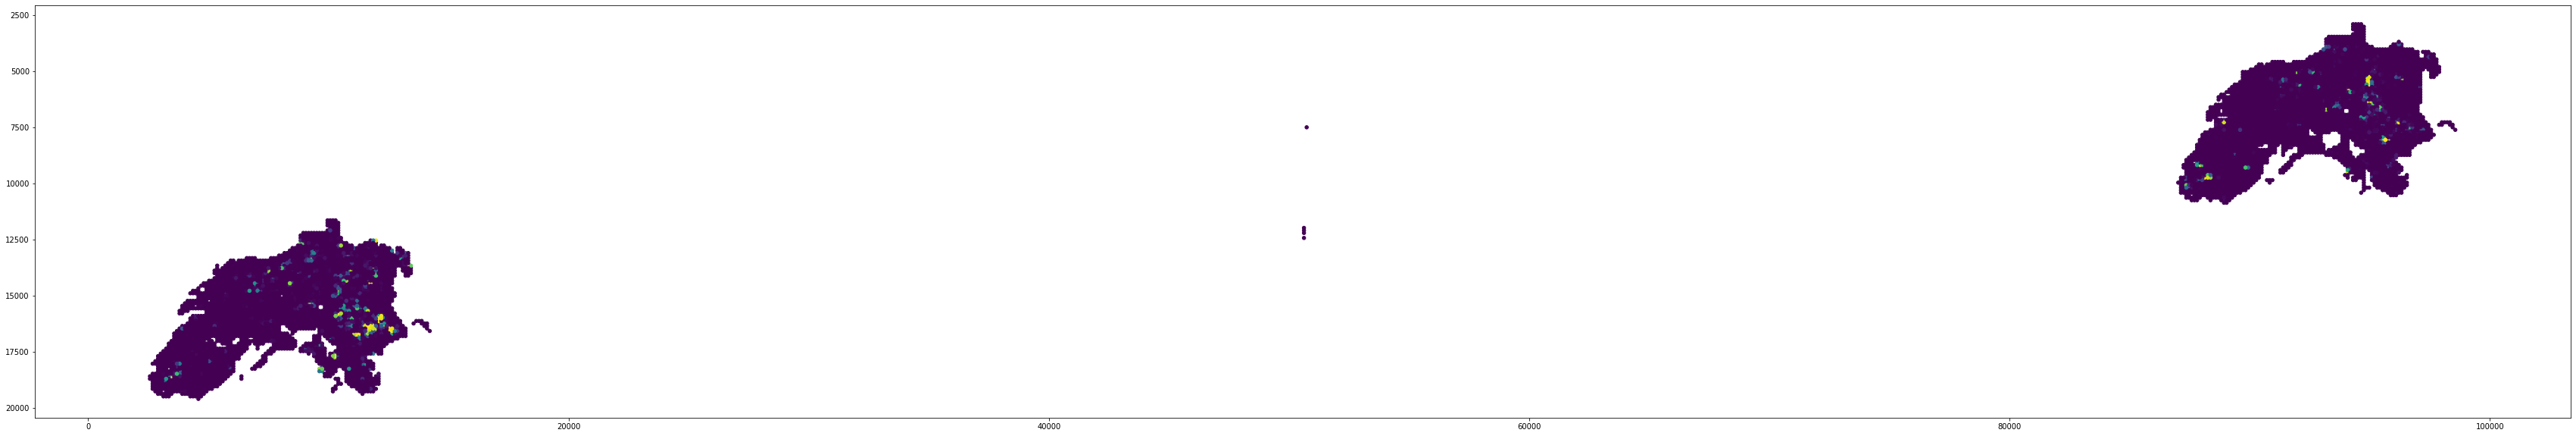

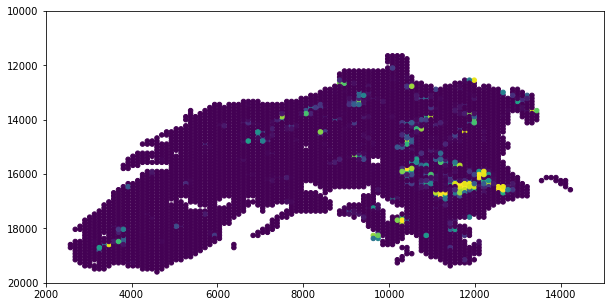

In [12]:
slide = 1007473
use = tile_df.slide == slide
fig = plt.figure(figsize=(60,10))
ax = fig.add_subplot(1,1,1)
ax.scatter(tile_df.y[use].values,
           tile_df.x[use].values,
           s = 20,
           c = tile_df.p_pos[use].values * 20)
ax.invert_yaxis()

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1)
ax.scatter(tile_df.y[use].values,
           tile_df.x[use].values,
           s = 20,
           c = tile_df.p_pos[use].values * 20)
ax.set_xlim([2000,15000])
ax.set_ylim([10e3,20e3])
ax.invert_yaxis()

# Custom p(pos) binning 

In [ ]:
slide = 1007482
use = tile_df.slide == slide
tsub=tile_df.loc[use,:].reset_index(drop=True)
dat = tsub.p_pos.values
pedge = [0, 1e-4,

# Look at average neighborhoods

[2.3306949e-19, 1.6597538e-07]
[1.6599532e-07, 8.5704363e-07]
[8.570608e-07, 2.6130247e-06]
[2.6130695e-06, 6.6449984e-06]
[6.6451694e-06, 1.5280224e-05]
[1.528037e-05, 3.3370972e-05]
[3.3372024e-05, 7.120561e-05]
[7.1206094e-05, 0.00015340053]
[0.00015340783, 0.0003436641]
[0.0003436928, 0.0008139474]
[0.0008139482, 0.0021406421]
[0.0021406626, 0.006389423]
[0.006389768, 0.022844505]
[0.022844516, 0.10245558]
[0.10246198, 0.44730905]
[0.44731876, 0.89797425]
[0.89798445, 0.9929132]
[0.99291354, 0.99966085]
[0.99966085, 0.99998987]
[0.99998987, 1.0]


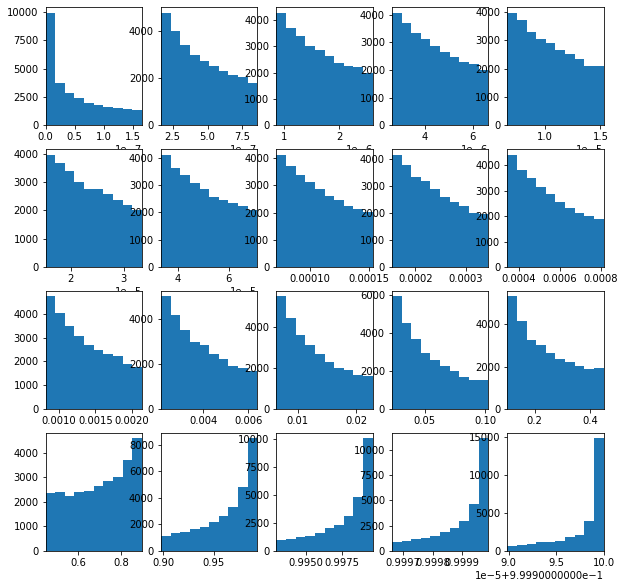

In [134]:
fig = plt.figure(figsize=(10,10))
quant_bin=[]
slide = 1007831
use = tile_df.slide == slide
tsub=tile_df.loc[use,:].reset_index(drop=True)
# dat = tsub.p_pos.values
dat = tile_df.p_pos.values
qidx = vector_to_quantile_index(dat, nq)
for q in range(0,nq):
    ax = fig.add_subplot(4,5,abs(q+1))
    d = dat[qidx==q]
    ax.hist(d)
    bins=[np.min(d),np.max(d)]
    print(bins)
    quant_bin.append(bins)
    ax.set_xlim(bins)

# V1 calculate via quantile method, v2 use standard probabilty bins

In [10]:
#V2
pbins = [[2.3306949e-19, 1.6597538e-07],
        [1.6599532e-07, 8.5704363e-07],
        [8.570608e-07, 2.6130247e-06],
        [2.6130695e-06, 6.6449984e-06],
        [6.6451694e-06, 1.5280224e-05],
        [1.528037e-05, 3.3370972e-05],
        [3.3372024e-05, 7.120561e-05],
        [7.1206094e-05, 0.00015340053],
        [0.00015340783, 0.0003436641],
        [0.0003436928, 0.0008139474],
        [0.0008139482, 0.0021406421],
        [0.0021406626, 0.006389423],
        [0.006389768, 0.022844505],
        [0.022844516, 0.10245558],
        [0.10246198, 0.44730905],
        [0.44731876, 0.89797425],
        [0.89798445, 0.9929132],
        [0.99291354, 0.99966085],
        [0.99966085, 0.99998987],
        [0.99998987, 1.0]]


1010279
0,5,14,19,
1007847
0,5,14,19,
1007831
0,5,14,19,
1007485
0,5,14,19,
1007482
0,5,14,19,
1007733
0,5,14,19,

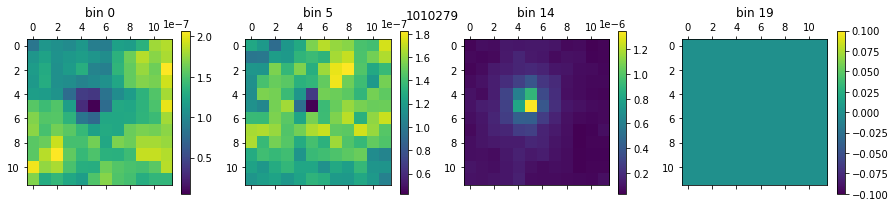

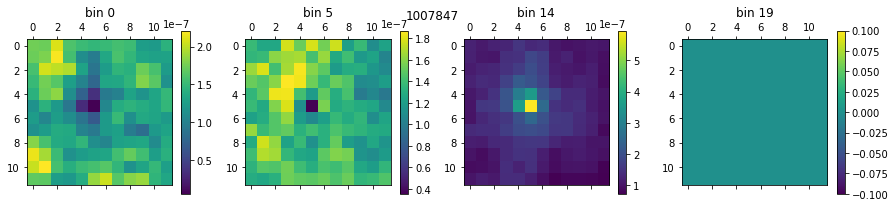

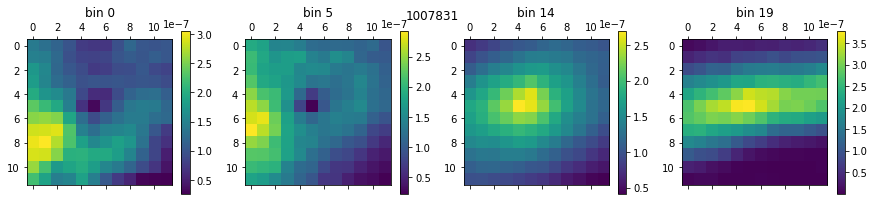

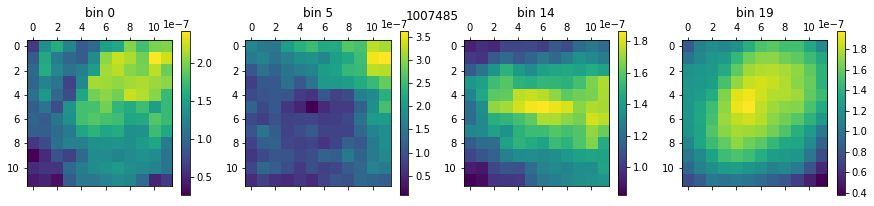

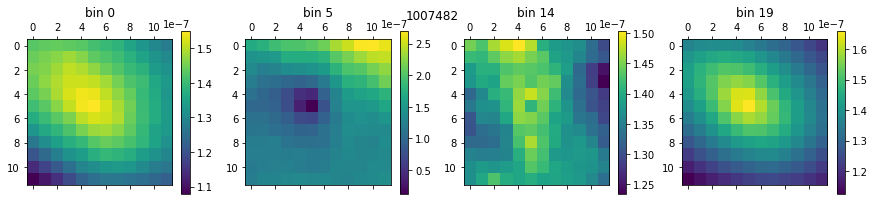

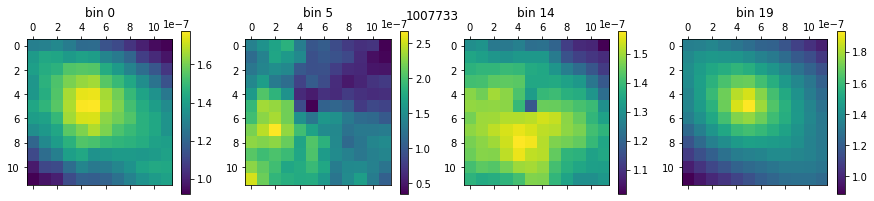

In [11]:
nq = 20
# nq = 10
n = 11 #num tile neighbors
p = n //2
ts = 224
slides = [ 1010279, 1007847, 1007831, 1007485,  1007482, 1007733] #Neg Neg, tricky Pos,Pos, Pos, Strong pos. V. strong pos
version = 2
for slide in slides:
    print('\n' + str(slide))
    use = tile_df.slide == slide
    tsub=tile_df.loc[use,:].reset_index(drop=True)
    dat = tsub.p_pos.values
    fig = plt.figure(figsize=(15,3))
    axi=1
    if version == 1:
        qidx = vector_to_quantile_index(dat, nq) #Do this instead with flat p-value bins from 0-1 ??
    elif version == 2:
        qidx = vector_to_pbins_index(dat,pbins)

    for i in [0,5,14,19]: #range(19,nq):
        print('%d,' % i, end='')
        idx = np.argwhere(qidx == i).flatten()         
        x_tot=[]
        y_tot=[]
        w_tot=[]
        if any(idx):
            for ii,tid in enumerate(idx):        
                xx,yy = tsub.loc[tid,['x','y']]
                xn = tsub.x.values - xx
                yn = tsub.y.values - yy
                keep = (xn >= -(p*ts)) & (xn < (p+2)*ts) \
                        & (yn >= -(p*ts)) & (yn < (p+2)*ts)
                x_tot.extend(xn[keep])
                y_tot.extend(yn[keep])
                w_tot.extend(dat[keep])
            x_bin = np.array([x for x in range(((-p * ts)),(p+3)*ts,ts)])
            y_bin = x_bin        
            nn,_,_ = np.histogram2d(x = x_tot,
                                    y = y_tot,
                                    bins = [x_bin,y_bin],
                                    density = True,
                                    weights = w_tot)
        else:
            nn = np.zeros((n+1,n+1))
        # ax = fig.add_subplot(4,5,abs(i+1))
        ax = fig.add_subplot(1,4,axi)
        im = ax.matshow(nn)
        plt.colorbar(im)
        ax.set_title('bin %d' % i)
        axi = axi + 1
    plt.suptitle(slide)

# Calculate neighborhood features for all P(Pos) bins and save to disk

In [157]:
nq = 20
n = 11 #num tile neighbors
p = n //2
ts = 224
slides = slide_df.slide_num.values
features = pd.DataFrame([])
version = 2
print(use_model)
for slide in slides:
    print('\n' + str(slide))
    use = tile_df.slide == slide
    tsub=tile_df.loc[use,:].reset_index(drop=True)
    dat = tsub.p_pos.values
    if version == 1:
        qidx = vector_to_quantile_index(dat, nq) #Do this instead with flat p-value bins from 0-1 ??
    elif version == 2:
        qidx = vector_to_pbins_index(dat,pbins)
    axi=1
    all_neighbors=[]
    for i in range(0,nq):
        print('%d,' % (i), end = '') # Way to prevent newline
        idx = np.argwhere(qidx == i).flatten()
        x_tot=[]
        y_tot=[]
        w_tot=[]
        if any(idx):
            for ii,tid in enumerate(idx):        
                xx,yy = tsub.loc[tid,['x','y']]
                xn = tsub.x.values - xx
                yn = tsub.y.values - yy
                keep = (xn >= -(p*ts)) & (xn < (p+2)*ts) \
                        & (yn >= -(p*ts)) & (yn < (p+2)*ts)
                x_tot.extend(xn[keep])
                y_tot.extend(yn[keep])
                w_tot.extend(dat[keep])
            x_bin = np.array([x for x in range(((-p * ts)),(p+3)*ts,ts)])
            y_bin = x_bin        
            nn,_,_ = np.histogram2d(x = x_tot,
                                    y = y_tot,
                                    bins = [x_bin,y_bin],
                                    density = True,
                                    weights = w_tot)
        else:
            nn = np.zeros((n+1,n+1))
        all_neighbors.extend(nn.ravel())
    features.loc[:,slide] = all_neighbors
tt = features.transpose()
fn = feat_path.joinpath('%dquantiles_%ddim_%dslides_neighborhood_normed_density_v%d.csv' % (nq,
                                                                                            (n+1),
                                                                                            tt.shape[0],
                                                                                            version))
print(fn)
tt.to_csv(fn)   

densenet169_10fold_1rep_1000bal_224px

1007831
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1010330
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1007828
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1010333
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1010328
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1010617
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1007825
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1007826
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1007827
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1007829
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1007821
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1007832
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1007830
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1007820
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1010331
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1010335
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
1007484
0,1,2,3,4

# Save local neighbor features

In [35]:
tt = features.transpose()
fn = feat_path.joinpath('%dquantiles_%ddim_%dslides_neighborhood_normed_density_v1.csv' % (nq,(n+1),tt.shape[0]))
print(fn)
tt.to_csv(fn)

/mnt/results/v8/features/densenet169_10fold_1rep_1000bal_224px/20quantiles_12dim_44slides_neighborhood_normed_density_v1.csv


# Load neighborhood features

In [3]:
tt = pd.read_csv('/mnt/results/v8/features/densenet169_1fold_1rep_10933bal_224px/20quantiles_12dim_44slides_neighborhood_normed_density_v2.csv',
                index_col=0)
tile_df = pd.read_csv('/mnt/results/v8/features/densenet169_1fold_1rep_10933bal_224px/tile_df_574187.csv')

tt.head(1)


,0,1,2,3,4,5,6,7,8,9,...,2870,2871,2872,2873,2874,2875,2876,2877,2878,2879
1007831,1.418703e-07,1.292004e-07,1.159608e-07,9.882572e-08,7.500743e-08,7.154976e-08,7.056839e-08,9.448653e-08,1.191379e-07,1.024495e-07,...,7.679271e-09,2.135293e-09,2.555445e-09,2.509886e-09,3.588846e-09,2.617368e-09,1.006751e-10,1.890981e-10,1.410493e-10,3.595208e-12


# Add more features

In [159]:
more_feat = tt.copy()
slides = slide_df.slide_num.values
best_t = 0.16
for slide in slides:
    use = tile_df.slide == slide
    tsub=tile_df.loc[use,:].reset_index(drop=True)
    dat = tsub.p_pos.values
    more_feat.loc[slide,'mean_ppos'] = np.mean(dat)
    more_feat.loc[slide,'median_ppos'] = np.median(dat)
    put_pos = dat>best_t
    more_feat.loc[slide,'prop_ppos'] = np.sum(put_pos)/len(dat)
    
    more_feat.loc[slide,'put_pos_mean'] = np.mean(dat[put_pos])
    more_feat.loc[slide,'put_pos_psum'] = np.sum(dat[put_pos])
    more_feat.loc[slide,'put_pos_std'] = np.std(dat[put_pos])
    more_feat.loc[slide,'put_pos_max'] = np.max(dat[put_pos])
    more_feat.loc[slide,'put_pos_min'] = np.min(dat[put_pos])
    
    # more_feat.loc[slide,'put_pos_mode'] = stats.mode(dat[put_pos])
    
    more_feat.loc[slide,'put_neg_max'] = np.max(dat[~put_pos])
    more_feat.loc[slide,'put_neg_psum'] = np.sum(dat[~put_pos])
    more_feat.loc[slide,'put_neg_mean'] = np.mean(dat[~put_pos])
    more_feat.loc[slide,'put_neg_min'] = np.min(dat[~put_pos])
    more_feat.loc[slide,'put_neg_std'] = np.std(dat[~put_pos])
    # more_feat.loc[slide,'put_neg_mode'] = stats.mode(dat[~put_pos])
    
more_feat.head(1)

,0,1,2,3,4,5,6,7,8,9,...,put_pos_mean,put_pos_psum,put_pos_std,put_pos_max,put_pos_min,put_neg_max,put_neg_psum,put_neg_mean,put_neg_min,put_neg_std
1007831,2.459558e-07,1.789429e-07,1.280933e-07,1.016799e-07,8.231239e-08,7.153194e-08,8.412079e-08,8.104430e-08,4.982857e-08,4.200686e-08,...,0.60269,2028.051064,0.289997,1.0,0.160074,0.1599,221.971719,0.006007,1.176604e-15,0.019894


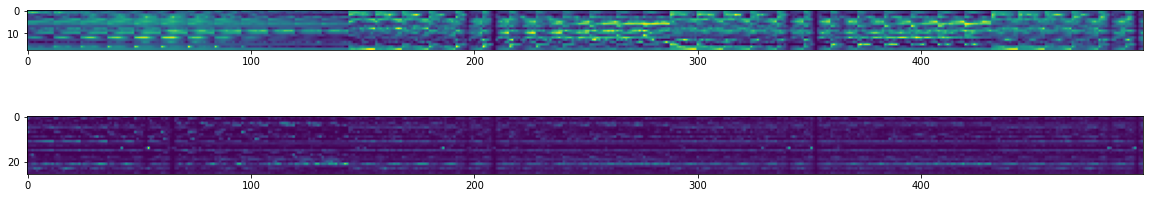

In [12]:
fig = plt.figure(figsize=(20,6))
ax = fig.add_subplot(3,1,1)
all_space = tt.copy()
all_space = (all_space.T - np.min(tt, axis=1)).T
all_space = (all_space.T / np.max(all_space, axis=1)).T
pos = slide_df.anno_class.str.contains('malig').values

ax.imshow(all_space.iloc[pos,0:500])

ax = fig.add_subplot(3,1,2)
ax.imshow(all_space.iloc[~pos,0:500])



Text(0.5, 0.98, 'Malignant slides')

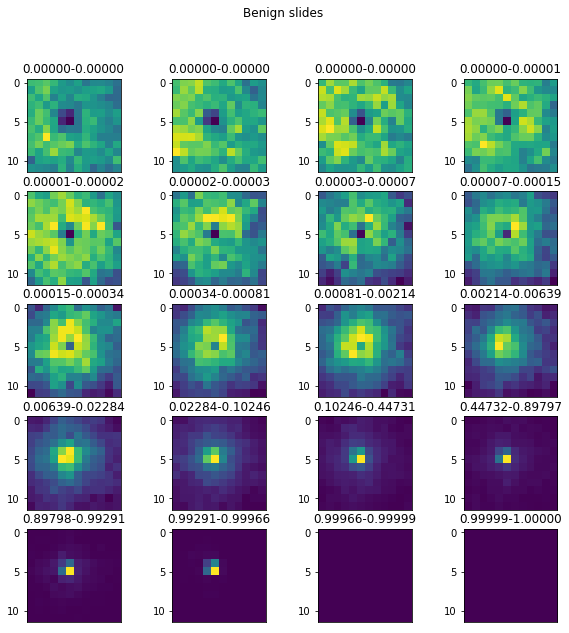

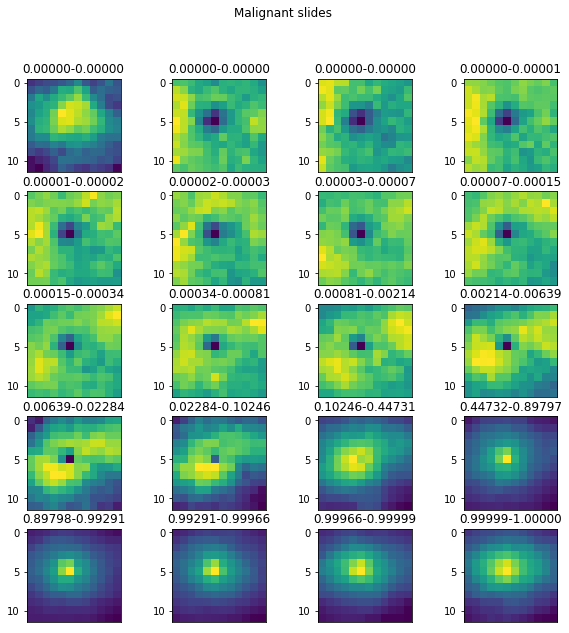

In [18]:
all_space = tt.copy()
all_space = (all_space.T - np.min(tt, axis=1)).T
all_space = (all_space.T / np.max(all_space, axis=1)).T

pos = slide_df.anno_class.str.contains('malig').values
ppd=np.median(all_space.iloc[pos,:].values,axis=0)
nd=np.median(all_space.iloc[~pos,:].values,axis=0)
dim = 12
cd = 0
fig = plt.figure(figsize=(10,10))
for i in range(0,20):
    dat = nd[cd:(cd+dim**2)]
    ax = fig.add_subplot(5,4,(i+1))
    ax.imshow(dat.reshape(dim,dim))
    ax.set_title('%1.5f-%1.5f' % tuple(pbins[i]))
    plt.xticks([])
    cd = cd + dim**2
plt.suptitle('Benign slides')
cd = 0
fig = plt.figure(figsize=(10,10))
for i in range(0,20):
    dat = ppd[cd:(cd+dim**2)]
    ax = fig.add_subplot(5,4,(i+1))
    ax.imshow(dat.reshape(dim,dim))
    ax.set_title('%1.5f-%1.5f' % tuple(pbins[i]))
    plt.xticks([])
    cd = cd + dim**2
plt.suptitle('Malignant slides')

# Try PCA on these features

In [14]:
pca = PCA(n_components = 44)
all_space = tt.copy()
all_space = (all_space.T - np.min(tt, axis=1)).T
all_space = (all_space.T / np.max(all_space, axis=1)).T
X_r0 = pca.fit(all_space).transform(all_space)
mf = more_feat.iloc[:,tt.shape[1]:].values
mf = mf - np.min(mf)
mf = mf / np.max(mf)
X = np.concatenate((mf,X_r0),axis=1)
# X = X_r0
# X = mf

# X_r = X_r0
pca = PCA(n_components = 2)
X_r = pca.fit(X).transform(X)

y = slide_df.anno_class.str.contains('malig').values
target_names=['Benign','Malig']
fig = plt.figure(figsize=(15,5))
colors = ["turquoise", "darkorange"]
lw = 2

ax = fig.add_subplot(1,2,1)
for color, i, target_name in zip(colors, [0, 1], target_names):
    ax.scatter(
        X_r[y == i, 0], X_r[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )
ax.legend(loc="best", shadow=False, scatterpoints=1)
ax.set_title("PCA of features")


kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
y = kmeans.labels_
ax = fig.add_subplot(1,2,2)
target_names=['kmeans 0', 'kmeans 1']
for color, i, target_name in zip(colors, [1,0], target_names):
    ax.scatter(
        X_r[y == i, 0], X_r[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )
ax.legend(loc="best", shadow=False, scatterpoints=1)
ax.set_title("Kmeans = 2 of features")

NameError: name 'more_feat' is not defined

# PCA on validation slides

Text(0.5, 1.0, 'Kmeans = 2 of features')

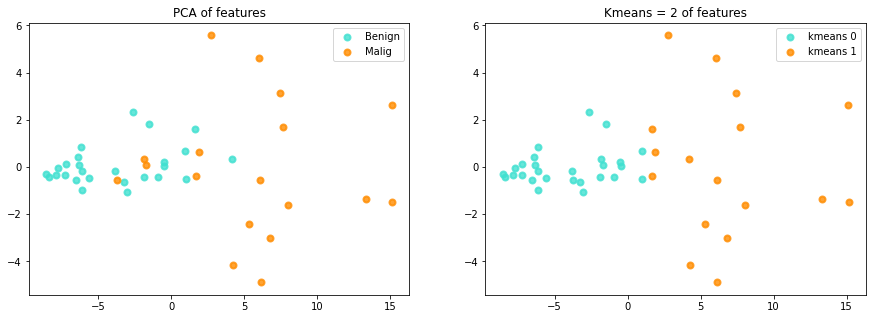

In [165]:
pca = PCA(n_components = 10)
all_space = tt.copy()
all_space = (all_space.T - np.min(tt, axis=1)).T
all_space = (all_space.T / np.max(all_space, axis=1)).T
X_r0 = pca.fit(all_space).transform(all_space)
mf = more_feat.iloc[:,tt.shape[1]:].values
mf = mf - np.min(mf)
mf = mf / np.max(mf)
X = np.concatenate((mf,X_r0),axis=1)
# X = X_r0
# X = mf

# X_r = X_r0
pca = PCA(n_components = 2)
X_r = pca.fit(X).transform(X)

y = slide_df.anno_class.str.contains('malig').values
target_names=['Benign','Malig']
fig = plt.figure(figsize=(15,5))
colors = ["turquoise", "darkorange"]
lw = 2

ax = fig.add_subplot(1,2,1)
for color, i, target_name in zip(colors, [0, 1], target_names):
    ax.scatter(
        X_r[y == i, 0], X_r[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )
ax.legend(loc="best", shadow=False, scatterpoints=1)
ax.set_title("PCA of features")


kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
y = kmeans.labels_
ax = fig.add_subplot(1,2,2)
target_names=['kmeans 0', 'kmeans 1']
for color, i, target_name in zip(colors, [0,1], target_names):
    ax.scatter(
        X_r[y == i, 0], X_r[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )
ax.legend(loc="best", shadow=False, scatterpoints=1)
ax.set_title("Kmeans = 2 of features")

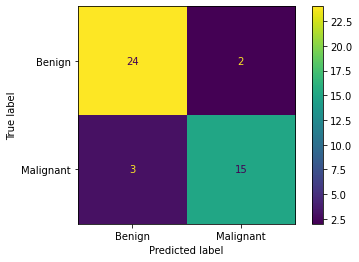

In [166]:
y_true = slide_df.anno_class.str.contains('malig').values == 1
y_pred = kmeans.labels_ == 1
cm = skm.confusion_matrix(y_true, y_pred)
disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['Benign','Malignant'])
disp.plot()